# Five-Bar Parallel Robot — Tutorial and Live Driver

The first half of this notebook is a tutorial on the inverse kinematics of this robot, with figures and an interactive widget. The second half opens the USB serial port and drives the physical Arduino. Run top to bottom on a fresh kernel.


## How the IK works

The robot has two motors fixed to a base and a single end-effector held jointly by two arms. Inverse kinematics means: given a desired end-effector position `(x, y)`, what motor angles do we need? The trick for this parallel mechanism is that the IK splits cleanly into two independent serial 2-link problems — one per arm — that happen to share the same end-effector. We can solve them one at a time using basic trigonometry.


In [38]:
%matplotlib widget

import sys
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from ipywidgets import interact, FloatSlider

sys.path.insert(0, str(Path.cwd().parent / "host"))
import five_bar_client as fbc


def setup_ax(ax, span_x=None, y_max=None, y_min=-10):
    if span_x is None:
        span_x = fbc.BASE_D / 2.0 + fbc.L1 + fbc.L2 + 10
    if y_max is None:
        y_max = fbc.L1 + fbc.L2 + 10
    ax.set_xlim(-span_x, +span_x)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")


def draw_linkage(ax, th1, th2, target=None):
    mL, eL, ee, eR, mR = fbc.forward_kinematics(th1, th2)
    ax.plot([mL[0], mR[0]], [mL[1], mR[1]], color="gray", lw=2)
    ax.plot([mL[0], eL[0]], [mL[1], eL[1]], color="tab:blue", lw=4)
    ax.plot([mR[0], eR[0]], [mR[1], eR[1]], color="tab:blue", lw=4)
    if ee is not None:
        ax.plot([eL[0], ee[0]], [eL[1], ee[1]], color="tab:orange", lw=2.5)
        ax.plot([eR[0], ee[0]], [eR[1], ee[1]], color="tab:orange", lw=2.5)
        ax.plot([ee[0]], [ee[1]], "o", color="tab:red", markersize=9)
    ax.plot(
        [mL[0], mR[0], eL[0], eR[0]],
        [mL[1], mR[1], eL[1], eR[1]],
        "o", color="black", markersize=6,
    )
    if target is not None:
        ax.plot([target[0]], [target[1]], "x", color="tab:red", markersize=10, mew=2)


### 1. The geometry

Two motors sit symmetrically on the base at `(±BASE_D/2, 0)`. Each motor drives a proximal link of length `L1`. At the far end of each proximal link, a passive hinge (the elbow) connects to a distal link of length `L2`. The two distal links meet at a single point — the end-effector.


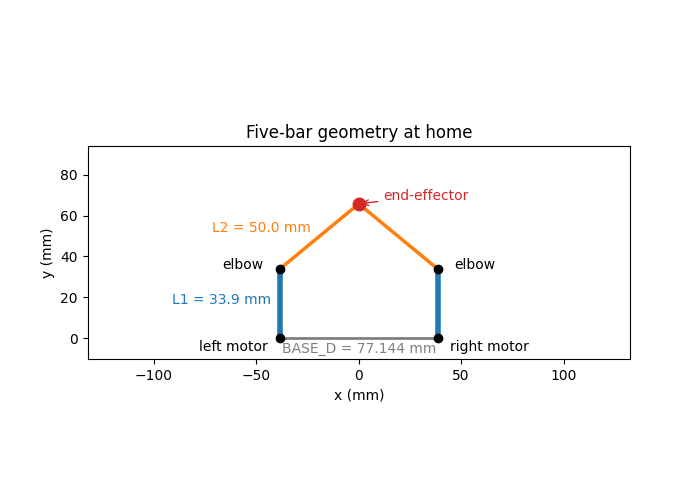

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))
setup_ax(ax)

th1, th2 = math.pi / 2, math.pi / 2
draw_linkage(ax, th1, th2)
mL, eL, ee, eR, mR = fbc.forward_kinematics(th1, th2)

ax.annotate("left motor", xy=mL, xytext=(mL[0] - 6, -6), ha="right")
ax.annotate("right motor", xy=mR, xytext=(mR[0] + 6, -6), ha="left")
ax.annotate("elbow", xy=eL, xytext=(eL[0] - 8, eL[1]), ha="right")
ax.annotate("elbow", xy=eR, xytext=(eR[0] + 8, eR[1]), ha="left")
ax.text((mL[0] + eL[0]) / 2 - 4, (mL[1] + eL[1]) / 2, f"L1 = {fbc.L1} mm",
        color="tab:blue", ha="right")
ax.text((eL[0] + ee[0]) / 2 - 4, (eL[1] + ee[1]) / 2 + 2, f"L2 = {fbc.L2} mm",
        color="tab:orange", ha="right")
ax.text(0, -7, f"BASE_D = {fbc.BASE_D} mm", color="gray", ha="center")
ax.annotate("end-effector", xy=ee, xytext=(ee[0] + 12, ee[1] + 2),
            color="tab:red",
            arrowprops=dict(arrowstyle="->", color="tab:red", lw=1))
ax.set_title("Five-bar geometry at home")
plt.show()


### 2. Each arm is a 2R serial chain

Forget about the parallel structure for a moment and look at just one arm. A motor at `M`, an elbow at `E`, and the end-effector at `T`. The motor controls the proximal link's angle. The elbow is passive — it just keeps `L1` and `L2` connected. So the question for one arm is: where must the elbow be so that `|ME| = L1` and `|ET| = L2` are both satisfied?


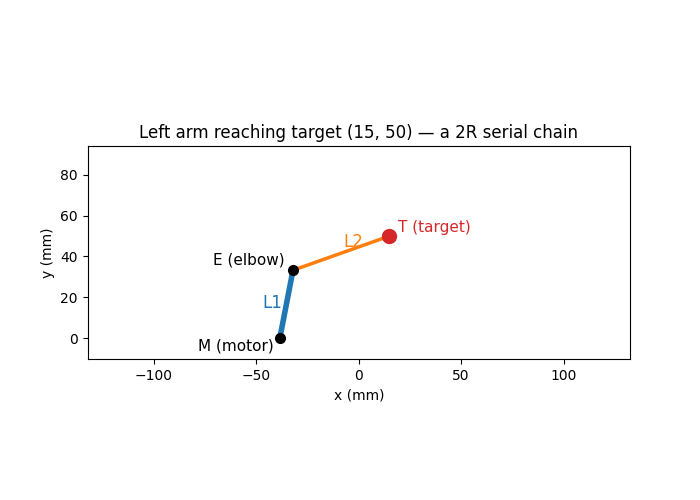

In [40]:
x, y = 15, 50
th1, th2 = fbc.solve_ik(x, y)
mL, eL, ee, _, _ = fbc.forward_kinematics(th1, th2)

fig, ax = plt.subplots(figsize=(7, 5))
setup_ax(ax)
ax.plot([mL[0], eL[0]], [mL[1], eL[1]], color="tab:blue", lw=4)
ax.plot([eL[0], ee[0]], [eL[1], ee[1]], color="tab:orange", lw=2.5)
ax.plot([mL[0], eL[0]], [mL[1], eL[1]], "o", color="black", markersize=7)
ax.plot([ee[0]], [ee[1]], "o", color="tab:red", markersize=10)

ax.annotate("M (motor)", xy=mL, xytext=(mL[0] - 3, -6), ha="right", fontsize=11)
ax.annotate("E (elbow)", xy=eL, xytext=(eL[0] - 4, eL[1] + 3), ha="right", fontsize=11)
ax.annotate("T (target)", xy=ee, xytext=(ee[0] + 4, ee[1] + 2),
            fontsize=11, color="tab:red")
ax.text((mL[0] + eL[0]) / 2 - 2, (mL[1] + eL[1]) / 2 - 2, "L1",
        color="tab:blue", ha="right", fontsize=12)
ax.text((eL[0] + ee[0]) / 2 + 1, (eL[1] + ee[1]) / 2 + 3, "L2",
        color="tab:orange", fontsize=12)
ax.set_title(f"Left arm reaching target ({x}, {y}) — a 2R serial chain")
plt.show()


### 3. A triangle with three known sides

Look at the points `M`, `E`, `T`. They form a triangle whose three sides we already know: `|ME| = L1`, `|ET| = L2`, and `|MT| = r = sqrt((x − Mx)² + (y − My)²)`. With all three sides in hand, the angle at the motor follows directly from the law of cosines:

$$\cos\alpha = \frac{L_1^2 + r^2 - L_2^2}{2\,L_1\,r}$$

The motor angle in world coordinates is then $\theta = \varphi + \alpha$, where $\varphi = \mathrm{atan2}(y - M_y,\ x - M_x)$ is the direction from the motor to the target.


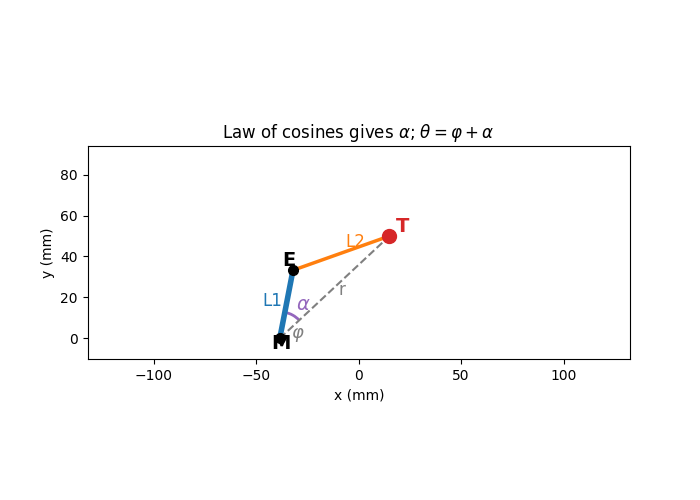

In [41]:
x, y = 15, 50
th1, th2 = fbc.solve_ik(x, y)
mL, eL, ee, _, _ = fbc.forward_kinematics(th1, th2)

phi = math.atan2(y - mL[1], x - mL[0])
r = math.hypot(x - mL[0], y - mL[1])
alpha = math.acos((fbc.L1**2 + r**2 - fbc.L2**2) / (2 * fbc.L1 * r))

fig, ax = plt.subplots(figsize=(7, 5))
setup_ax(ax)

ax.plot([mL[0], eL[0]], [mL[1], eL[1]], color="tab:blue", lw=4)
ax.plot([eL[0], ee[0]], [eL[1], ee[1]], color="tab:orange", lw=2.5)
ax.plot([mL[0], ee[0]], [mL[1], ee[1]], color="gray", lw=1.5, ls="--")
ax.plot([mL[0], eL[0]], [mL[1], eL[1]], "o", color="black", markersize=7)
ax.plot([ee[0]], [ee[1]], "o", color="tab:red", markersize=10)

ax.annotate("M", xy=mL, xytext=(mL[0] - 4, mL[1] - 5), fontsize=14, fontweight="bold")
ax.annotate("E", xy=eL, xytext=(eL[0] - 5, eL[1] + 2), fontsize=14, fontweight="bold")
ax.annotate("T", xy=ee, xytext=(ee[0] + 3, ee[1] + 2), fontsize=14, fontweight="bold",
            color="tab:red")
ax.text((mL[0] + eL[0]) / 2 - 2, (mL[1] + eL[1]) / 2 - 1, "L1",
        color="tab:blue", ha="right", fontsize=12)
ax.text((eL[0] + ee[0]) / 2 + 2, (eL[1] + ee[1]) / 2 + 3, "L2",
        color="tab:orange", fontsize=12)
ax.text((mL[0] + ee[0]) / 2 + 2, (mL[1] + ee[1]) / 2 - 4, "r",
        color="gray", fontsize=12)

arc_r = 13
arc = Arc((mL[0], mL[1]), 2 * arc_r, 2 * arc_r,
          angle=0,
          theta1=math.degrees(phi), theta2=math.degrees(phi + alpha),
          color="tab:purple", lw=2)
ax.add_patch(arc)
mid = phi + alpha / 2
ax.text(mL[0] + (arc_r + 3) * math.cos(mid),
        mL[1] + (arc_r + 3) * math.sin(mid),
        r"$\alpha$", color="tab:purple", fontsize=14, fontweight="bold")
phi_mid = phi / 2
ax.text(mL[0] + 6 * math.cos(phi_mid), mL[1] + 6 * math.sin(phi_mid) - 2,
        r"$\varphi$", color="gray", fontsize=13)

ax.set_title(r"Law of cosines gives $\alpha$; $\theta = \varphi + \alpha$")
plt.show()


### 4. Two solutions per arm

Picking `α` (or equivalently, `−α`) places the elbow on either side of the motor–target line. Both elbow positions are at distance `L1` from the motor and `L2` from the target — both satisfy the constraints. The mechanism, once built, can only sit in one of the two; we have to pick a convention.


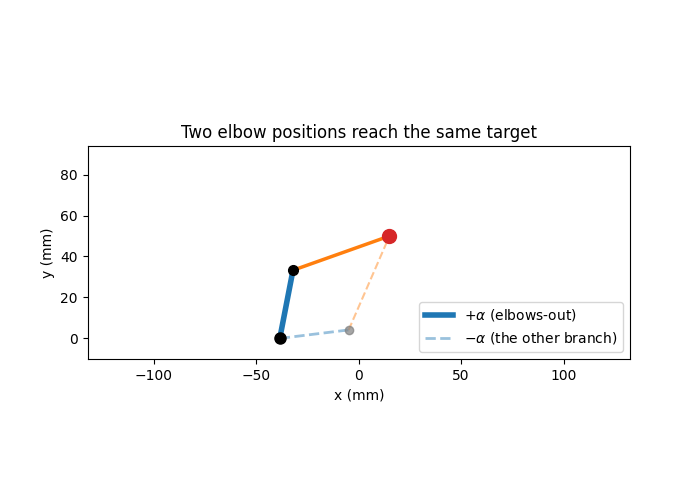

In [42]:
x, y = 15, 50
mL = (-fbc.BASE_D / 2.0, 0.0)
dx, dy = x - mL[0], y - mL[1]
r = math.hypot(dx, dy)
phi = math.atan2(dy, dx)
alpha = math.acos((fbc.L1**2 + r**2 - fbc.L2**2) / (2 * fbc.L1 * r))

elbow_plus = (mL[0] + fbc.L1 * math.cos(phi + alpha),
              mL[1] + fbc.L1 * math.sin(phi + alpha))
elbow_minus = (mL[0] + fbc.L1 * math.cos(phi - alpha),
               mL[1] + fbc.L1 * math.sin(phi - alpha))

fig, ax = plt.subplots(figsize=(7, 5))
setup_ax(ax)

ax.plot([mL[0], elbow_plus[0]], [mL[1], elbow_plus[1]], color="tab:blue", lw=4,
        label=r"$+\alpha$ (elbows-out)")
ax.plot([elbow_plus[0], x], [elbow_plus[1], y], color="tab:orange", lw=2.5)

ax.plot([mL[0], elbow_minus[0]], [mL[1], elbow_minus[1]], color="tab:blue",
        lw=2, ls="--", alpha=0.45, label=r"$-\alpha$ (the other branch)")
ax.plot([elbow_minus[0], x], [elbow_minus[1], y], color="tab:orange",
        lw=1.5, ls="--", alpha=0.45)

ax.plot([mL[0]], [mL[1]], "o", color="black", markersize=8)
ax.plot([elbow_plus[0]], [elbow_plus[1]], "o", color="black", markersize=7)
ax.plot([elbow_minus[0]], [elbow_minus[1]], "o", color="gray", markersize=6, alpha=0.7)
ax.plot([x], [y], "o", color="tab:red", markersize=10)

ax.legend(loc="lower right")
ax.set_title("Two elbow positions reach the same target")
plt.show()


### 5. Elbows-out working mode

The firmware uses one consistent convention: the left arm picks `+α` (its elbow sits counter-clockwise of the line of sight) and the right arm picks `−α` (clockwise). The two elbows therefore splay outward — hence "elbows-out". Each arm is solved independently with this rule, and because both solutions were computed for the same `(x, y)`, the two distal links meet at that point.


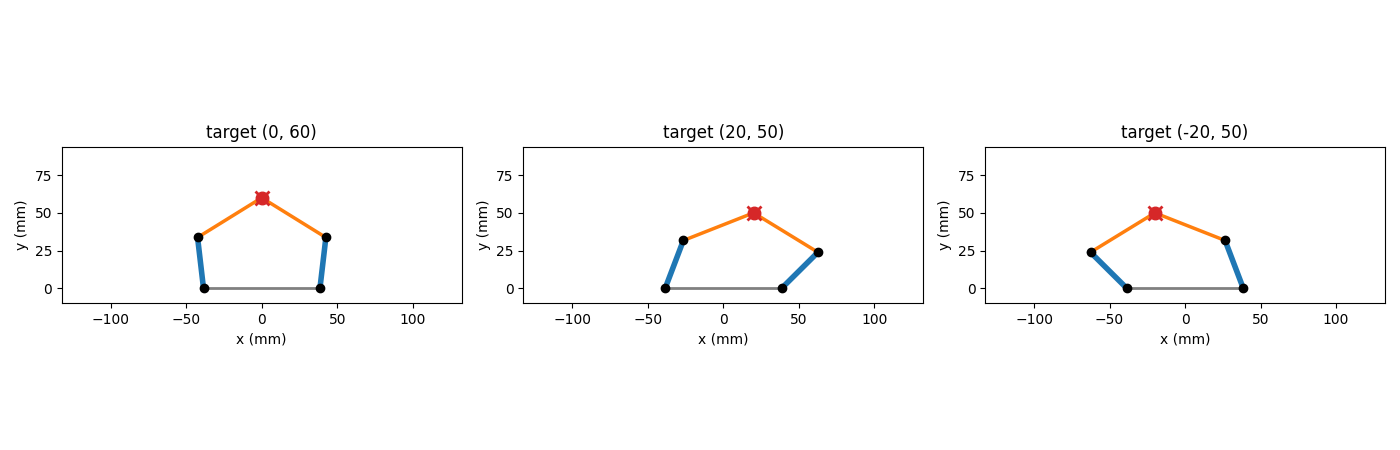

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (x, y) in zip(axes, [(0, 60), (20, 50), (-20, 50)]):
    setup_ax(ax)
    th1, th2 = fbc.solve_ik(x, y)
    draw_linkage(ax, th1, th2, target=(x, y))
    ax.set_title(f"target ({x}, {y})")
plt.tight_layout()
plt.show()


### 6. Try it yourself

Drag the sliders. The plot shows the solved linkage and prints the two motor angles and the parallel-singularity clearance. Out-of-range targets show no linkage.


interactive(children=(FloatSlider(value=0.0, description='x (mm)', max=40.0, min=-40.0, step=1.0), FloatSlider…

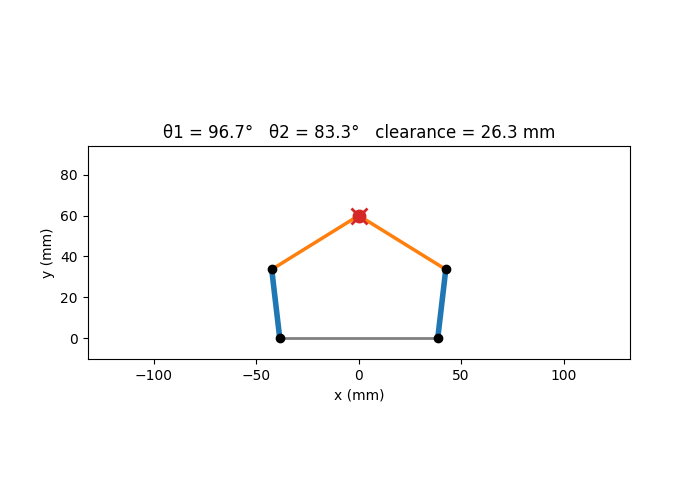

In [44]:
fig_i, ax_i = plt.subplots(figsize=(7, 5))
setup_ax(ax_i)

base_line, = ax_i.plot([], [], color="gray", lw=2)
pL, = ax_i.plot([], [], color="tab:blue", lw=4)
pR, = ax_i.plot([], [], color="tab:blue", lw=4)
dL, = ax_i.plot([], [], color="tab:orange", lw=2.5)
dR, = ax_i.plot([], [], color="tab:orange", lw=2.5)
joints, = ax_i.plot([], [], "o", color="black", markersize=6)
ee_dot, = ax_i.plot([], [], "o", color="tab:red", markersize=9)
target_x, = ax_i.plot([], [], "x", color="tab:red", markersize=12, mew=2)


def update(x, y):
    target_x.set_data([x], [y])
    sol = fbc.solve_ik(x, y)
    if sol is None:
        for ln in (base_line, pL, pR, dL, dR, joints, ee_dot):
            ln.set_data([], [])
        ax_i.set_title(f"target ({x:.0f}, {y:.0f}) — OOR")
        fig_i.canvas.draw_idle()
        return
    th1, th2 = sol
    mL, eL, ee, eR, mR = fbc.forward_kinematics(th1, th2)
    base_line.set_data([mL[0], mR[0]], [mL[1], mR[1]])
    pL.set_data([mL[0], eL[0]], [mL[1], eL[1]])
    pR.set_data([mR[0], eR[0]], [mR[1], eR[1]])
    dL.set_data([eL[0], ee[0]], [eL[1], ee[1]])
    dR.set_data([eR[0], ee[0]], [eR[1], ee[1]])
    joints.set_data([mL[0], mR[0], eL[0], eR[0]], [mL[1], mR[1], eL[1], eR[1]])
    ee_dot.set_data([ee[0]], [ee[1]])
    clear = fbc.singularity_clearance(x, y)
    flag = "  (near singularity)" if clear < fbc.SINGULARITY_MARGIN_MM else ""
    ax_i.set_title(
        f"\u03b81 = {math.degrees(th1):.1f}\u00b0   "
        f"\u03b82 = {math.degrees(th2):.1f}\u00b0   "
        f"clearance = {clear:.1f} mm{flag}"
    )
    fig_i.canvas.draw_idle()


interact(update,
         x=FloatSlider(min=-40, max=40, step=1, value=0, description="x (mm)"),
         y=FloatSlider(min=30, max=75, step=1, value=60, description="y (mm)"));


### 7. Workspace and singularities

Not every `(x, y)` is reachable. Beyond the outer boundary, one arm runs out of length (serial singularity). Closer to the base, the two elbows splay almost to maximum separation and the distal links become colinear (parallel singularity) — the linkage loses mechanical advantage and the motors can stall. The host-side `singularity_clearance` flags the parallel case before sending a `move`.


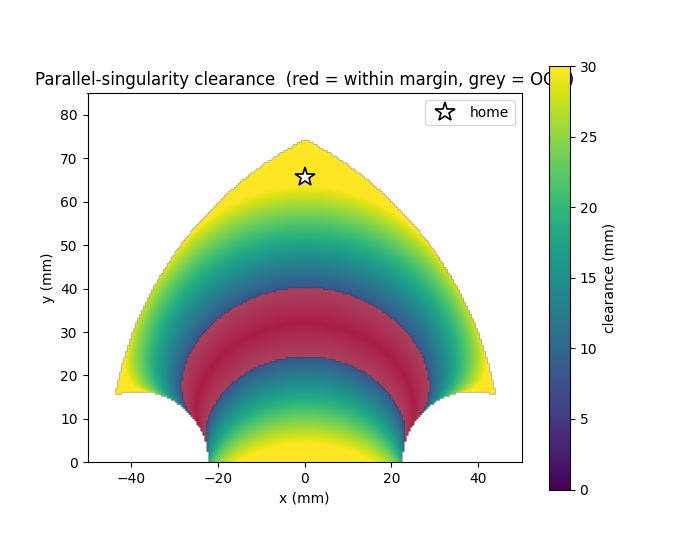

In [45]:
nx, ny = 220, 180
xs = np.linspace(-50, 50, nx)
ys = np.linspace(0, 85, ny)
grid = np.full((ny, nx), np.nan)
for j, yy in enumerate(ys):
    for i, xx in enumerate(xs):
        c = fbc.singularity_clearance(xx, yy)
        if c is not None:
            grid[j, i] = c

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.imshow(np.zeros((ny, nx)), extent=[xs[0], xs[-1], ys[0], ys[-1]],
          origin="lower", cmap="Greys", vmin=0, vmax=1, alpha=0.25)
im = ax.imshow(grid, extent=[xs[0], xs[-1], ys[0], ys[-1]],
               origin="lower", cmap="viridis", vmin=0, vmax=30)

mask = (grid < fbc.SINGULARITY_MARGIN_MM) & ~np.isnan(grid)
red = np.zeros((ny, nx, 4))
red[mask] = [1.0, 0.2, 0.2, 0.55]
ax.imshow(red, extent=[xs[0], xs[-1], ys[0], ys[-1]], origin="lower")

ax.plot([0], [fbc._HOME_XY[1]], marker="*", color="white", markersize=15,
        markeredgecolor="black", markeredgewidth=1.2, linestyle="None", label="home")
ax.set_aspect("equal")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title("Parallel-singularity clearance  (red = within margin, grey = OOR)")
ax.legend(loc="upper right")
fig.colorbar(im, ax=ax, label="clearance (mm)")
plt.show()


---

## Drive the robot

The cells below open the USB serial port, draw a live figure synced to the physical robot, and provide `move`, `home`, `release`, and `status` helpers. Flash the firmware in `firmware/five_bar_ik/` and power the robot before running them.


In [46]:
%matplotlib widget

import sys
import time
import math
from pathlib import Path

import matplotlib.pyplot as plt
import serial

sys.path.insert(0, str(Path.cwd().parent / "host"))
import five_bar_client as fbc


In [ ]:
# Re-running this cell pulses DTR and resets the Arduino.
ser = serial.Serial("/dev/ttyUSB1", 115200, timeout=1.0)
time.sleep(2.0)
fbc.wait_for_ready(ser)


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
span_x = fbc.BASE_D / 2.0 + fbc.L1 + fbc.L2 + 10
ax.set_xlim(-span_x, +span_x)
ax.set_ylim(-10, fbc.L1 + fbc.L2 + 10)
ax.set_aspect("equal")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")

base_line, = ax.plot([], [], color="gray", linewidth=2)
prox_left, = ax.plot([], [], color="tab:blue", linewidth=4)
prox_right, = ax.plot([], [], color="tab:blue", linewidth=4)
dist_left, = ax.plot([], [], color="tab:orange", linewidth=2.5)
dist_right, = ax.plot([], [], color="tab:orange", linewidth=2.5)
joints, = ax.plot([], [], "o", color="black", markersize=6)
ee_dot, = ax.plot([], [], "o", color="tab:red", markersize=9)

current = (math.pi / 2.0, math.pi / 2.0)

def redraw(th1, th2, title_xy=None):
    mL, eL, ee, eR, mR = fbc.forward_kinematics(th1, th2)
    base_line.set_data([mL[0], mR[0]], [mL[1], mR[1]])
    prox_left.set_data([mL[0], eL[0]], [mL[1], eL[1]])
    prox_right.set_data([mR[0], eR[0]], [mR[1], eR[1]])
    if ee is not None:
        dist_left.set_data([eL[0], ee[0]], [eL[1], ee[1]])
        dist_right.set_data([eR[0], ee[0]], [eR[1], ee[1]])
        ee_dot.set_data([ee[0]], [ee[1]])
    joints.set_data(
        [mL[0], mR[0], eL[0], eR[0]],
        [mL[1], mR[1], eL[1], eR[1]],
    )
    if title_xy is not None:
        ax.set_title(f"target ({title_xy[0]:.1f}, {title_xy[1]:.1f}) mm")
    fig.canvas.draw_idle()

redraw(*current, title_xy=fbc._HOME_XY)


In [ ]:
DEG_PER_SEC = 1000.0 / 8.0  # match firmware moveSmooth pacing
FRAME_DT = 1.0 / 30.0

def _tween(target, title_xy):
    global current
    c1, c2 = current
    t1, t2 = target
    max_d = max(abs(t1 - c1), abs(t2 - c2))
    duration = math.degrees(max_d) / DEG_PER_SEC
    if duration <= 0.0:
        redraw(t1, t2, title_xy=title_xy)
        current = target
        return
    t0 = time.time()
    while True:
        frac = min((time.time() - t0) / duration, 1.0)
        th1 = c1 + (t1 - c1) * frac
        th2 = c2 + (t2 - c2) * frac
        redraw(th1, th2, title_xy=title_xy)
        fig.canvas.flush_events()
        if frac >= 1.0:
            break
        time.sleep(FRAME_DT)
    current = target


def move(x, y):
    sol = fbc.solve_ik(x, y)
    if sol is None:
        print(f"host: OOR ({x}, {y})")
        return
    clear = fbc.singularity_clearance(x, y)
    if clear is not None and clear < fbc.SINGULARITY_MARGIN_MM:
        print(f"warn: near singularity (clearance {clear:.1f} mm)")
    reply = fbc.send(ser, f"M {x} {y}")
    if not reply.startswith("OK"):
        return
    _tween(sol, (x, y))


def home():
    reply = fbc.send(ser, "H")
    if not reply.startswith("OK"):
        return
    _tween((math.pi / 2.0, math.pi / 2.0), fbc._HOME_XY)


def release():
    fbc.send(ser, "R")


def status():
    fbc.send(ser, "S")


### Demo

Each cell below is a single statement — edit the numbers and re-run.

In [ ]:
home()


In [ ]:
move(0, 60)


In [ ]:
move(20, 50)


In [ ]:
move(-20, 50)


In [ ]:
move(0, 40)


In [ ]:
home()


### Drawing a circle

A circle is a useful test trajectory: it's smooth, closed, and easy to parameterize. We pick a centre `(cx, cy)` and a radius `r`, then sample `N` waypoints by stepping the angle `θ` from `0` to `2π`:

$$x_i = c_x + r\cos\theta_i,\qquad y_i = c_y + r\sin\theta_i$$

Each waypoint becomes one `move(x, y)` call. The firmware smoothly interpolates the joint angles between waypoints and the host figure animates in lockstep. We pick a centre just below the home pose and a modest radius so the entire path stays well inside the singularity-safe zone — the next cell previews the path and checks the parallel-singularity clearance at every point.


In [ ]:
import numpy as np

# Circle parameters. Centre is below home; radius is small enough to keep the
# whole path clear of both the outer-extension and parallel singularities.
cx, cy = 0.0, 60.0
radius = 10.0
n_points = 60

# Sample N angles around the full circle. endpoint=False avoids duplicating
# the start point at the end of the loop.
theta = np.linspace(0.0, 2.0 * np.pi, n_points, endpoint=False)
xs = cx + radius * np.cos(theta)
ys = cy + radius * np.sin(theta)

# Preview the planned path so we can eyeball it before driving the robot.
fig_pv, ax_pv = plt.subplots(figsize=(6, 6))
ax_pv.set_xlim(-50, 50)
ax_pv.set_ylim(0, 85)
ax_pv.set_aspect("equal")
ax_pv.set_xlabel("x (mm)")
ax_pv.set_ylabel("y (mm)")
ax_pv.plot(xs, ys, "-o", color="tab:blue", markersize=4, linewidth=1, label="waypoints")
ax_pv.plot([xs[0]], [ys[0]], "o", color="tab:green", markersize=10, label="start")
ax_pv.plot([0], [fbc._HOME_XY[1]], "*", color="tab:red", markersize=12, label="home")
ax_pv.set_title(f"Planned circle: centre ({cx}, {cy}), radius {radius} mm, {n_points} pts")
ax_pv.legend(loc="upper right")
plt.show()

# Sanity check: every waypoint must be reachable, and ideally well clear of the
# parallel singularity. If min_clearance dips below SINGULARITY_MARGIN_MM the
# robot will still try, but motion will degrade near the singular band.
clearances = [fbc.singularity_clearance(float(x), float(y)) for x, y in zip(xs, ys)]
assert all(c is not None for c in clearances), "some waypoint is unreachable"
print(f"min clearance: {min(clearances):.2f} mm  (margin = {fbc.SINGULARITY_MARGIN_MM} mm)")


In [ ]:
# Drive the real robot around the circle.
# Each move() call sends the M command, waits for the firmware's OK reply,
# and tweens the on-screen linkage so the visual stays in sync with the
# physical motion. The loop blocks until each waypoint is reached.
for x, y in zip(xs, ys):
    move(float(x), float(y))

# Park back at home when the circle is done.
home()


### Cleanup

Run before shutting down the kernel — releases the servos and closes the port.

In [ ]:
release()
ser.close()
